# Clase 2 · Ejercicio 2.3 — Diagnosticar antes de actuar

**Curso:** Diseño de red 4G/5G · **Duración:** 60 min

Se te entrega un despliegue de 3 gNB sobre Múnich que rinde por debajo de lo deseable.
Tu tarea: **averiguar qué lo limita** y elegir la palanca correcta.

> **La trampa de este ejercicio.** El libro de texto dice que en una red móvil subir la
> potencia no mejora la SINR, porque señal e interferencia crecen juntas. Eso es cierto
> **solo en redes limitadas por interferencia**. Antes de aplicar la regla hay que
> comprobar que se cumple la condición. Aquí no se cumple, y los datos te lo van a decir.

## 0 · Entorno

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import drjit as dr
import sionna
from sionna.rt import (load_scene, PlanarArray, Transmitter,
                       RadioMapSolver, scene as scenes)

print("Sionna", sionna.__version__)
print("Backend LLVM (CPU):", bool(dr.has_backend(dr.JitBackend.LLVM)))
print("Backend CUDA (GPU):", bool(dr.has_backend(dr.JitBackend.CUDA)))

Sionna 2.0.1
Backend LLVM (CPU): True
Backend CUDA (GPU): True


**Presupuesto de rayos.** El llenado del mapa depende del muestreo. Con pocos rayos
quedan huecos que parecen agujeros de cobertura pero son ruido de Monte Carlo.

| Rayos | `max_depth` | Área cubierta | Tiempo (16 hilos) |
|---|---|---|---|
| 5×10⁷ | 6 | parcial | ~20 s |
| 2×10⁸ | 8 | 92 % | ~95 s |

Empieza con el ajuste rápido para explorar; usa el fino para las cifras del informe.

In [2]:
N_HILOS = 8
dr.set_thread_count(N_HILOS)

RAPIDO = dict(rayos=int(5e7), celda=5.0, profundidad=6)
FINO   = dict(rayos=int(2e8), celda=5.0, profundidad=8)
AJUSTE = RAPIDO          # cambia a FINO para las cifras finales

## 1 · Funciones de evaluación

In [3]:
RUIDO_W = 10**((-174 + 10*np.log10(100e6) + 7 - 30)/10)   # 100 MHz, NF 7 dB

def construir_escena(sitios, frecuencia=3.5e9):
    sc = load_scene(scenes.munich, merge_shapes=True)
    sc.frequency = frecuencia
    for i, s in enumerate(sitios):
        sc.tx_array = PlanarArray(num_rows=s.get("filas", 4), num_cols=s.get("cols", 4),
                                  vertical_spacing=0.5, horizontal_spacing=0.5,
                                  pattern="tr38901", polarization="V")
        # OJO: Mitsuba exige float de Python, no np.float64
        sc.add(Transmitter(name=f"gnb{i}",
                           position=[float(v) for v in s["pos"]],
                           orientation=[float(s.get("acimut", 0.0)),
                                        float(np.deg2rad(-s.get("tilt", 0.0))), 0.0],
                           power_dbm=float(s.get("potencia", 44.0))))
    return sc

def evaluar(sitios, ajuste=None, verbose=True, etiqueta=""):
    """Devuelve (potencia_dbm, sinr_db, metricas)."""
    a = ajuste or AJUSTE
    sc = construir_escena(sitios)
    dr.sync_thread(); t0 = time.time()
    rm = RadioMapSolver()(sc, cell_size=(a["celda"], a["celda"]),
                          samples_per_tx=a["rayos"], max_depth=a["profundidad"],
                          refraction=True, diffuse_reflection=True)
    rss = np.asarray(rm.rss.numpy())
    dr.sync_thread(); dt = time.time() - t0

    cubierto = rss.sum(axis=0) > 0
    pot_dbm = np.where(cubierto, 10*np.log10(rss.sum(axis=0) + 1e-30) + 30, np.nan)
    ordenado = np.sort(rss, axis=0)
    servidor, interf = ordenado[-1], ordenado[:-1].sum(axis=0)
    with np.errstate(divide="ignore"):
        sinr_db = np.where(cubierto, 10*np.log10(servidor/(interf + RUIDO_W)), np.nan)

    m = {"etiqueta": etiqueta or f"{len(sitios)} sitios", "t_s": dt, "n_sitios": len(sitios),
         "sinr_pos": float(np.nanmean(sinr_db > 0)),
         "pot_ok":   float(np.nanmean(pot_dbm > -110)),
         "sin_pot":  float(np.nanmean(~(pot_dbm > -110))),
         "potok_sinr_mala": float(np.nanmean((pot_dbm > -110) & (sinr_db < 0))),
         "sinr_p05": float(np.nanpercentile(sinr_db, 5)),
         "sinr_p50": float(np.nanpercentile(sinr_db, 50))}
    if verbose:
        print(f"[{dt:5.1f}s] {m['etiqueta']:<22} SINR>0 {m['sinr_pos']*100:5.1f}% | "
              f"potOK {m['pot_ok']*100:5.1f}% | SINR p05/p50 {m['sinr_p05']:6.1f}/{m['sinr_p50']:5.1f} dB")
    return pot_dbm, sinr_db, m

## 2 · El paso que no puedes saltarte: ¿qué limita esta red?

Cada punto del mapa cae en una de tres categorías:

| Categoría | Condición | Qué la arregla |
|---|---|---|
| Sin cobertura | potencia < −110 dBm | más potencia, más sitios, menos frecuencia |
| Limitado por interferencia | potencia OK **pero** SINR < 0 | geometría: *tilt*, sectorización, reubicar |
| Servido | potencia OK y SINR > 0 | nada |

Un reflejo común es contar qué categoría es mayor y decidir con eso. **No basta.** Esa
razón depende del muestreo, y sobre todo no te dice si en la zona ya servida el
denominador de la SINR está dominado por el ruido o por las celdas vecinas — que es lo
que realmente decide si la potencia sirve de algo.

El diagnóstico fiable es medir las tres palancas. Eso es el apartado 3.

In [4]:
despliegue_base = [
    {"pos": (-100.,  50., 40.), "potencia": 44.0, "tilt": 0.0},
    {"pos": ( 150., -80., 40.), "potencia": 44.0, "tilt": 0.0},
    {"pos": (  30., 200., 40.), "potencia": 44.0, "tilt": 0.0},
]

pot_base, sinr_base, m_base = evaluar(despliegue_base, etiqueta="entregado")

print(f"\n  sin cobertura (pot < -110 dBm)      {m_base['sin_pot']*100:5.1f} %")
print(f"  limitado por interferencia          {m_base['potok_sinr_mala']*100:5.1f} %")
print(f"  servido (pot OK y SINR > 0)         {m_base['sinr_pos']*100:5.1f} %")

razon = m_base["potok_sinr_mala"] / max(m_base["sin_pot"], 1e-9)
print(f"\n  razon interferencia/cobertura = {razon:.1f}")
print("  OJO: esta razon NO basta para decidir la palanca.")
print("  Depende del muestreo (con pocos rayos sobreestima la falta de cobertura)")
print("  y, sobre todo, no dice si el RUIDO domina donde si hay servicio.")
print("  El unico diagnostico fiable es el experimento del apartado 3.")

[  1.7s] entregado              SINR>0  58.5% | potOK  76.1% | SINR p05/p50  -16.5/  8.1 dB

  sin cobertura (pot < -110 dBm)       23.9 %
  limitado por interferencia           17.6 %
  servido (pot OK y SINR > 0)          58.5 %

  razon interferencia/cobertura = 0.7
  OJO: esta razon NO basta para decidir la palanca.
  Depende del muestreo (con pocos rayos sobreestima la falta de cobertura)
  y, sobre todo, no dice si el RUIDO domina donde si hay servicio.
  El unico diagnostico fiable es el experimento del apartado 3.


## 3 · Las tres palancas, medidas

Prueba las tres sobre el mismo escenario y compara. No adelantes la conclusión: mide.

In [5]:
resultados = {"entregado": m_base}

# (a) potencia: +6 dB en todos los sitios
_, _, m_pot = evaluar([dict(s, potencia=50.0) for s in despliegue_base],
                      etiqueta="+6 dB")
resultados["potencia"] = m_pot

# (b) tilt: barrido
for t in [6, 12]:
    _, _, m_t = evaluar([dict(s, tilt=float(t)) for s in despliegue_base],
                        etiqueta=f"tilt {t}deg")
    resultados[f"tilt{t}"] = m_t

# (c) densificacion: un cuarto sitio
cuarto = {"pos": (-50., -150., 30.), "potencia": 41.0, "tilt": 0.0}
_, _, m_4 = evaluar(despliegue_base + [cuarto], etiqueta="4 sitios")
resultados["densificar"] = m_4

[  1.0s] +6 dB                  SINR>0  65.2% | potOK  77.0% | SINR p05/p50  -10.6/ 11.2 dB
[  1.6s] tilt 6deg              SINR>0  58.6% | potOK  76.1% | SINR p05/p50  -16.6/  8.0 dB
[  1.0s] tilt 12deg             SINR>0  57.9% | potOK  76.1% | SINR p05/p50  -16.7/  7.3 dB
[  1.3s] 4 sitios               SINR>0  63.7% | potOK  79.3% | SINR p05/p50  -12.7/  9.4 dB


In [6]:
print(f"{'Palanca':<22}{'SINR>0':>9}{'vs base':>10}{'pot OK':>9}")
print("-"*50)
for k, m in resultados.items():
    d = (m["sinr_pos"] - m_base["sinr_pos"])*100
    print(f"{m['etiqueta']:<22}{m['sinr_pos']*100:>8.1f}%{d:>+9.1f}pp{m['pot_ok']*100:>8.1f}%")

Palanca                  SINR>0   vs base   pot OK
--------------------------------------------------
entregado                 58.5%     +0.0pp    76.1%
+6 dB                     65.2%     +6.6pp    77.0%
tilt 6deg                 58.6%     +0.1pp    76.1%
tilt 12deg                57.9%     -0.6pp    76.1%
4 sitios                  63.7%     +5.2pp    79.3%


### Lo que deberías estar viendo

Con muestreo fino (2×10⁸ rayos) las cifras verificadas son:

| Palanca | SINR > 0 | vs. base |
|---|---|---|
| Entregado (3 sitios, 44 dBm) | 67.0 % | — |
| **+6 dB de potencia** | **74.9 %** | **+7.9 pp** |
| *Tilt* 6° | 66.8 % | −0.2 pp |
| *Tilt* 12° | 65.5 % | −1.5 pp |
| Cuarto sitio (44 dBm) | 71.8 % | +4.8 pp |

**La potencia gana y el *tilt* no hace nada.** Esto contradice la regla de manual.
¿Por qué?

Mira el diagnóstico del apartado 2: **9 % del área sin cobertura frente a 24 % limitada por
interferencia**. Suena a red limitada por interferencia — pero ese 24 % está concentrado en
las fronteras entre celdas, y el resto del mapa tiene un servidor claramente dominante con
poca interferencia. En esos puntos el denominador de la SINR está gobernado por el **ruido**,
no por las celdas vecinas:

$$\mathrm{SINR} = \frac{P G_{\text{serv}}}{\underbrace{\textstyle\sum_{j} P G_j}_{\text{pequeño}} + N}
\;\approx\; \frac{P G_{\text{serv}}}{N}$$

Cuando $N$ domina, subir $P$ **sí** sube la SINR proporcionalmente. La regla de manual
solo aplica cuando el primer término del denominador aplasta a $N$, y eso requiere una red
mucho más densa que tres sitios repartidos en un kilómetro cuadrado.

### Por qué el *tilt* no ayuda aquí (aunque el mecanismo funciona)

Que el *tilt* no mueva la SINR **no** significa que no haga nada. Mide su efecto físico
directamente, con un solo transmisor y sin interferencia de por medio:

In [7]:
def perfil_radial(tilt_deg, rayos=int(3e7)):
    """Potencia media por anillo de distancia, un solo TX."""
    sc = load_scene(scenes.munich, merge_shapes=True)
    sc.frequency = 3.5e9
    sc.tx_array = PlanarArray(num_rows=4, num_cols=4, vertical_spacing=0.5,
                              horizontal_spacing=0.5, pattern="tr38901", polarization="V")
    sc.add(Transmitter(name="t", position=[0., 0., 40.],
                       orientation=[0., float(np.deg2rad(-tilt_deg)), 0.], power_dbm=44.))
    rm = RadioMapSolver()(sc, cell_size=(5., 5.), samples_per_tx=rayos, max_depth=5,
                          refraction=False, diffuse_reflection=False)
    r = np.asarray(rm.rss.numpy())[0]
    ny, nx = r.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    d = np.sqrt((xx - nx/2)**2 + (yy - ny/2)**2) * 5.0
    out = []
    for lo, hi in [(0,100),(100,200),(200,400),(400,800)]:
        m = (d >= lo) & (d < hi) & (r > 0)
        out.append(10*np.log10(r[m].mean() + 1e-30) + 30 if m.sum() else np.nan)
    return out

anillos = ["0-100 m", "100-200 m", "200-400 m", "400-800 m"]
print(f"{'tilt':>5}  " + "  ".join(f"{a:>10}" for a in anillos))
perfiles = {}
for t in [0, 10, 20]:
    perfiles[t] = perfil_radial(t)
    print(f"{t:4d}°  " + "  ".join(f"{v:10.1f}" for v in perfiles[t]))

 tilt     0-100 m   100-200 m   200-400 m   400-800 m
   0°       -76.9       -56.4       -54.2       -59.3
  10°       -75.1       -64.6       -59.6       -63.0
  20°       -72.4       -67.9       -70.3       -72.3


Verificado: a 20° de inclinación la potencia cercana sube **+4.5 dB** y la lejana cae
**−13 dB**. El haz se está recogiendo exactamente como predice la teoría.

**Entonces, ¿por qué no mejora la SINR?** Porque con 3 sitios separados cientos de metros,
esa energía que dejas de radiar lejos no estaba llegando a la celda vecina como
interferencia: estaba cubriendo tu propio borde de celda. Recoger el haz te quita cobertura
propia sin quitarte interferencia ajena.

**El *tilt* es la palanca correcta en redes densas, donde las celdas se solapan.** Aquí no
lo es. Elegir la palanca sin diagnosticar primero es el error que este ejercicio te enseña
a no cometer.

## 4 · Tu turno: combina palancas

Ninguna palanca sola llega muy lejos. Combínalas. Tienes presupuesto para **un sitio
adicional** y libertad para ajustar potencia, altura, *tilt* y posición.

Referencia verificada de la mejor combinación encontrada:

| Configuración | SINR > 0 |
|---|---|
| 4 sitios a 44 dBm | 71.8 % |
| 3 sitios a 50 dBm + *tilt* 6° | 74.8 % |
| **4 sitios a 50 dBm** | **78.5 %** |

¿Puedes superar el 78.5 %? Pistas: la potencia ayuda porque hay margen de ruido, pero
llega un punto en que el área pasa a estar limitada por interferencia y deja de ayudar —
vigila la columna `potok_sinr_mala` para detectar cuándo cruzas ese umbral.

In [8]:
mi_despliegue = [
    {"pos": (-100.,  50., 40.), "potencia": 50.0, "tilt": 0.0},
    {"pos": ( 150., -80., 40.), "potencia": 50.0, "tilt": 0.0},
    {"pos": (  30., 200., 40.), "potencia": 50.0, "tilt": 0.0},
    {"pos": ( -50.,-150., 30.), "potencia": 47.0, "tilt": 0.0},
]

pot_mi, sinr_mi, m_mi = evaluar(mi_despliegue, etiqueta="mi diseño")
print(f"\n  limitado por interferencia: {m_mi['potok_sinr_mala']*100:.1f} % "
      f"(base: {m_base['potok_sinr_mala']*100:.1f} %)")
print("  -> si este numero sube mucho, ya estas en regimen de interferencia:")
print("     a partir de ahi la potencia deja de ayudar y toca geometria")

[  1.3s] mi diseño              SINR>0  70.0% | potOK  79.8% | SINR p05/p50   -6.8/ 12.3 dB

  limitado por interferencia: 9.8 % (base: 17.6 %)
  -> si este numero sube mucho, ya estas en regimen de interferencia:
     a partir de ahi la potencia deja de ayudar y toca geometria


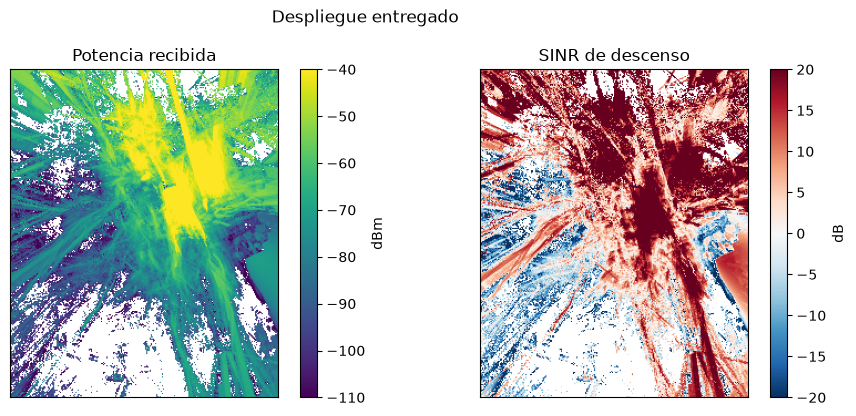

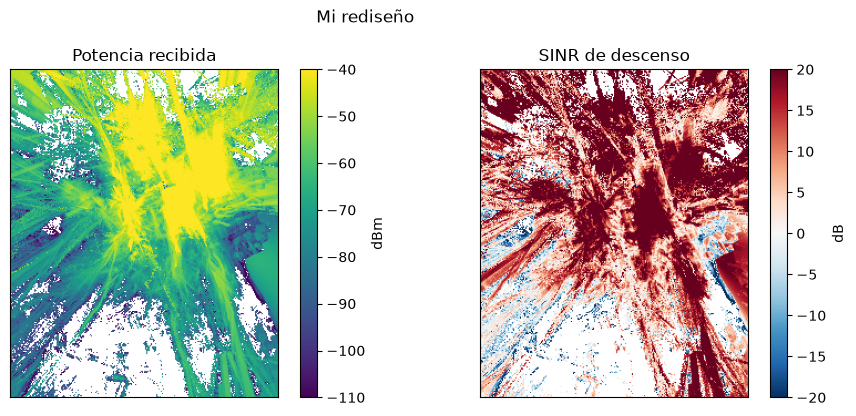

In [9]:
def dibujar(pot_dbm, sinr_db, titulo=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2))
    im1 = ax1.imshow(pot_dbm.T, origin="lower", cmap="viridis",
                     vmin=-110, vmax=-40, aspect="equal")
    ax1.set_title("Potencia recibida"); ax1.set_xticks([]); ax1.set_yticks([])
    fig.colorbar(im1, ax=ax1, fraction=0.046).set_label("dBm")
    im2 = ax2.imshow(sinr_db.T, origin="lower", cmap="RdBu_r",
                     vmin=-20, vmax=20, aspect="equal")
    ax2.set_title("SINR de descenso"); ax2.set_xticks([]); ax2.set_yticks([])
    fig.colorbar(im2, ax=ax2, fraction=0.046).set_label("dB")
    if titulo: fig.suptitle(titulo)
    fig.tight_layout()
    return fig

fig1 = dibujar(pot_base, sinr_base, "Despliegue entregado")
fig2 = dibujar(pot_mi, sinr_mi, "Mi rediseño")

## 5 · Entregable

Informe de una página con:

1. **Diagnóstico.** ¿Qué limita la red entregada? Cita el reparto sin cobertura /
   interferencia / servido.
2. **La regla y su condición.** Enuncia la regla de manual sobre potencia y SINR, indica
   bajo qué condición vale, y muestra con tus datos si aquí se cumple.
3. **Las tres palancas medidas**, con la tabla comparativa.
4. **Por qué el *tilt* no funcionó**, apoyándote en el perfil radial. Distingue entre "el
   mecanismo no funciona" y "el mecanismo funciona pero no es lo que limita aquí".
5. **Tu diseño final** con mapas antes/después.
6. **Una limitación de esta simulación.** *Pista: aquí no hay usuarios pidiendo tráfico.
   Eso es la Clase 3.*

**Criterio de evaluación.** El informe que aplica la regla de manual sin comprobar su
condición previa suspende, aunque el diseño final funcione. El objetivo del ejercicio es el
diagnóstico, no el número.